Universidad Torcuato Di Tella

Licenciatura en Tecnología Digital\
**Tecnología Digital VI: Inteligencia Artificial**

# **GANs**

Este archivo IPYNB está basado en el siguiente recurso: https://www.kaggle.com/code/niharika41298/gans-for-cats.

In [ ]:
import os
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
import torchvision.transforms as tt
import torch
import torch.nn as nn
import cv2
from tqdm.notebook import tqdm
import torch.nn.functional as F
from torchvision.utils import save_image
from torchvision.utils import make_grid
import matplotlib.pyplot as plt
from google.colab import drive
import time
%matplotlib inline
torch.manual_seed(0)

In [ ]:
drive.mount('/content/drive', force_remount = True)

Mounted at /content/drive


In [ ]:
dir = '/content/drive/My Drive/cat-faces'

In [ ]:
# Imprimimos los nombres de las primeras 20 imágenes.
print(os.listdir(dir + '/cats')[ :20])

['962.jpg', '9030.jpg', '8877.jpg', '9487.jpg', '8843.jpg', '9926 (1).jpg', '9954.jpg', '8848.jpg', '9386.jpg', '8723.jpg', '9989.jpg', '885.jpg', '9449.jpg', '9723.jpg', '8900.jpg', '9227.jpg', '8870.jpg', '8780.jpg', '9368.jpg', '9653.jpg']


In [ ]:
st = time.time()
image_size = 64
batch_size = 128
stats = (0.5, 0.5, 0.5), (0.5, 0.5, 0.5)

train_ds = ImageFolder(dir, transform = tt.Compose([tt.Resize(image_size),
                                                    tt.CenterCrop(image_size),
                                                    tt.ToTensor(),
                                                    tt.Normalize(*stats)]))

train_dl = DataLoader(train_ds, batch_size, shuffle = True, num_workers = 3, pin_memory = True)
elapsed_time = time.time() - st
print('Execution time:', elapsed_time, 'seconds')

Execution time: 1.0144906044006348 seconds


/usr/local/lib/python3.10/dist-packages/torch/utils/data/dataloader.py:557: UserWarning: This DataLoader will create 3 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(


In [ ]:
def denorm(img_tensors):
  return img_tensors * stats[1][0] + stats[0][0]

In [ ]:
def show_images(images, nmax = 64):
    fig, ax = plt.subplots(figsize = (8, 8))
    ax.set_xticks([]); ax.set_yticks([])
    ax.imshow(make_grid(denorm(images.detach()[:nmax]), nrow = 8).permute(1, 2, 0))

def show_batch(dl, nmax = 64):
    for images, _ in dl:
        show_images(images, nmax)
        break

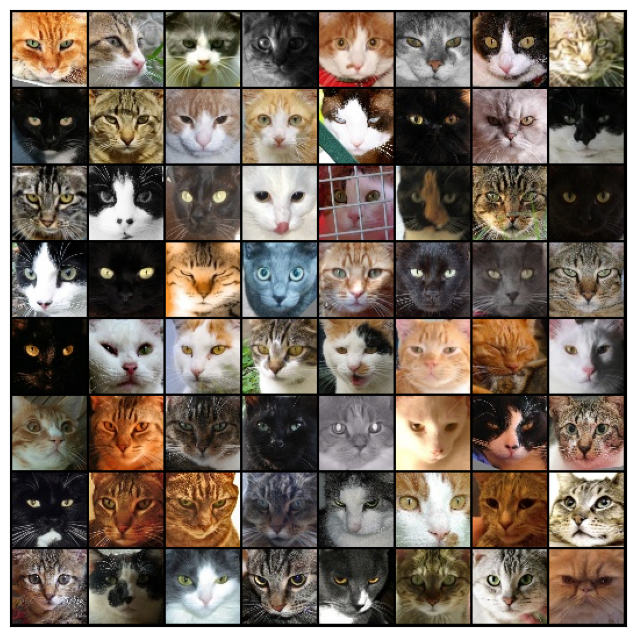

In [ ]:
# Aclaración: esto tarda bastante en ejecutarse en Google Colab.
show_batch(train_dl)

In [ ]:
def is_cuda_available():
    if torch.cuda.is_available():
        print("CUDA available. Training on GPU!")
        return torch.device('cuda')
    else:
        print("CUDA not available. Training on CPU!")
        return torch.device('cpu')

In [ ]:
def to_device(data, device):
    '''Mueve el/los tensor/es al dispositivo elegido.'''
    if isinstance(data, (list, tuple)):
        return [to_device(x, device) for x in data]
    return data.to(device, non_blocking = True)

In [ ]:
class DeviceDataLoader():
    '''Envuelve a un dataloader para mover data a un dispositivo.'''
    def __init__(self, dl, device):
        self.dl = dl
        self.device = device

    def __iter__(self):
        '''Cede un lote de datos luego de moverlo al dispositivo.'''
        for b in self.dl:
            yield to_device(b, self.device)

    def __len__(self):
        '''Devuelve el número de lotes.'''
        return len(self.dl)

In [ ]:
is_cuda_available()

CUDA available. Training on GPU!


device(type='cuda')

In [ ]:
device = is_cuda_available()
train_dl = DeviceDataLoader(train_dl, device)

CUDA available. Training on GPU!


In [ ]:
# CNN básica con capas convolucionales y LeakyReLU como función de activación.
discriminator = nn.Sequential(
    # in: 3 x 64 x 64.

    nn.Conv2d(3, 64, kernel_size = 4, stride = 2, padding = 1, bias = False),
    nn.BatchNorm2d(64),
    nn.LeakyReLU(0.2, inplace = True),
    # out: 64 x 32 x 32.

    nn.Conv2d(64, 128, kernel_size = 4, stride = 2, padding = 1, bias = False),
    nn.BatchNorm2d(128),
    nn.LeakyReLU(0.2, inplace = True),
    # out: 128 x 16 x 16.

    nn.Conv2d(128, 256, kernel_size = 4, stride = 2, padding = 1, bias = False),
    nn.BatchNorm2d(256),
    nn.LeakyReLU(0.2, inplace = True),
    # out: 256 x 8 x 8.

    nn.Conv2d(256, 512, kernel_size = 4, stride = 2, padding = 1, bias = False),
    nn.BatchNorm2d(512),
    nn.LeakyReLU(0.2, inplace = True),
    # out: 512 x 4 x 4.

    nn.Conv2d(512, 1, kernel_size = 4, stride = 1, padding = 0, bias = False),
    # out: 1 x 1 x 1.

    nn.Flatten(),
    nn.Sigmoid())

In [ ]:
discriminator = to_device(discriminator, device)

In [ ]:
latent_size = 128
generator = nn.Sequential(
    # in: latent_size x 1 x 1.

    nn.ConvTranspose2d(latent_size, 512, kernel_size = 4, stride = 1, padding = 0, bias = False),
    nn.BatchNorm2d(512),
    nn.ReLU(True),
    # out: 512 x 4 x 4.

    nn.ConvTranspose2d(512, 256, kernel_size = 4, stride = 2, padding = 1, bias = False),
    nn.BatchNorm2d(256),
    nn.ReLU(True),
    # out: 256 x 8 x 8.

    nn.ConvTranspose2d(256, 128, kernel_size = 4, stride = 2, padding = 1, bias = False),
    nn.BatchNorm2d(128),
    nn.ReLU(True),
    # out: 128 x 16 x 16.

    nn.ConvTranspose2d(128, 64, kernel_siz = 4, stride = 2, padding = 1, bias = False),
    nn.BatchNorm2d(64),
    nn.ReLU(True),
    # out: 64 x 32 x 32.

    nn.ConvTranspose2d(64, 3, kernel_size = 4, stride = 2, padding = 1, bias = False),
    nn.Tanh()
    # out: 3 x 64 x 64.
)

torch.Size([128, 3, 64, 64])


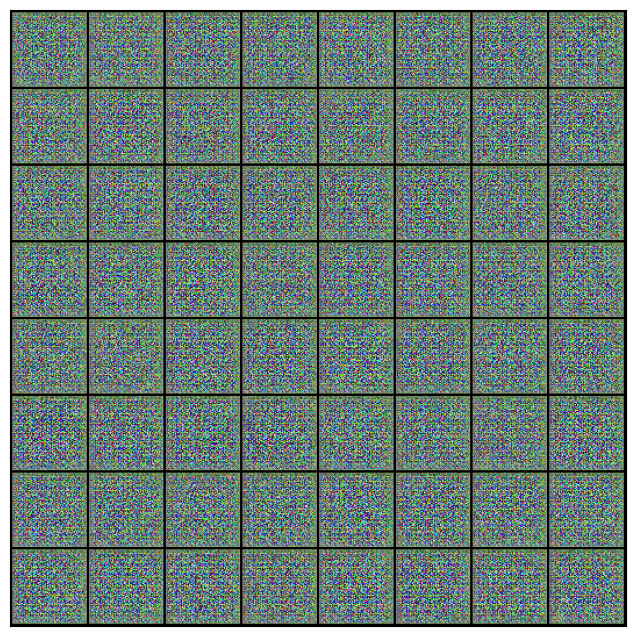

In [ ]:
xb = torch.randn(batch_size, latent_size, 1, 1) # Tensores latentes aleatorios.
fake_images = generator(xb)
print(fake_images.shape)
show_images(fake_images)

In [ ]:
generator = to_device(generator, device)

In [ ]:
def train_discriminator(real_images, opt_d):
    # Ponemos los gradientes en 0.
    opt_d.zero_grad()

    # Entrenamos el discriminador con imágenes reales.
    real_preds = discriminator(real_images)
    # Queremos que devuelva 1 para las imágenes reales.
    real_targets = torch.ones(real_images.size(0), 1, device = device)
    real_loss = F.binary_cross_entropy(real_preds, real_targets)
    real_score = torch.mean(real_preds).item()

    # Generamos imágenes falsas.
    latent = torch.randn(batch_size, latent_size, 1, 1, device = device)
    fake_images = generator(latent)

    # Pasamos imágenes falsas al discriminador.
    # Queremos que devuelva 0 para las imágenes falsas.
    fake_targets = torch.zeros(fake_images.size(0), 1, device = device)
    fake_preds = discriminator(fake_images)
    fake_loss = F.binary_cross_entropy(fake_preds, fake_targets)
    fake_score = torch.mean(fake_preds).item()

    # Actualizamos los pesos del discriminador.
    loss = real_loss + fake_loss
    loss.backward()
    opt_d.step()
    return loss.item(), real_score, fake_score

In [ ]:
def train_generator(opt_g):
    # Ponemos en 0 los gradientes del generador.
    opt_g.zero_grad()

    # Generamos imágenes falsas.
    latent = torch.randn(batch_size, latent_size, 1, 1, device = device)
    fake_images = generator(latent)

    # Intentamos "engañar" al discriminador.
    preds = discriminator(fake_images)
    # En el caso del generador, queremos que el discriminador devuelva 1 para las imágenes falsas.
    targets = torch.ones(batch_size, 1, device=device)
    loss = F.binary_cross_entropy(preds, targets)

    # Actualizamos los pesos del discriminador.
    loss.backward()
    opt_g.step()

    return loss.item()

In [ ]:
sample_dir = '/content/drive/My Drive/generated'
os.makedirs(sample_dir, exist_ok = True)

In [ ]:
def save_samples(index, latent_tensors, show = True):
    fake_images = generator(latent_tensors)
    fake_fname = 'generated-images-{0:0=4d}.png'.format(index)
    save_image(denorm(fake_images), os.path.join(sample_dir, fake_fname), nrow = 8)
    print('Saving', fake_fname)
    if show:
        fig, ax = plt.subplots(figsize = (8, 8))
        ax.set_xticks([]); ax.set_yticks([])
        ax.imshow(make_grid(denorm(fake_images).cpu().detach(), nrow = 8).permute(1, 2, 0))

In [ ]:
fixed_latent = torch.randn(64, latent_size, 1, 1, device = device)

Saving generated-images-0000.png


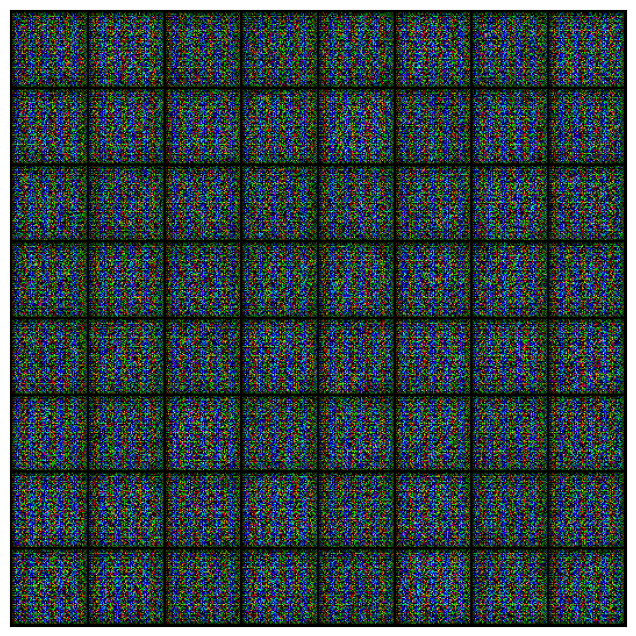

In [ ]:
save_samples(0, fixed_latent)

In [ ]:
def fit(epochs, lr, start_idx = 1):
    torch.cuda.empty_cache()

    # Losses & scores.
    losses_g = []
    losses_d = []
    real_scores = []
    fake_scores = []

    # Optimizadores.
    opt_d = torch.optim.Adam(discriminator.parameters(), lr = lr, betas = (0.5, 0.999))
    opt_g = torch.optim.Adam(generator.parameters(), lr = lr, betas = (0.5, 0.999))

    for epoch in range(epochs):
        st = time.time()
        for real_images, _ in tqdm(train_dl):
            # Entrenamos al discriminador.
            loss_d, real_score, fake_score = train_discriminator(real_images, opt_d)
            # Entrenamos al generador.
            loss_g = train_generator(opt_g)

        # Guardamos las pérdidas y los scores.
        losses_g.append(loss_g)
        losses_d.append(loss_d)
        real_scores.append(real_score)
        fake_scores.append(fake_score)

        # Logueamos pérdidas y scores del último batch.
        print("Epoch [{}/{}], loss_g: {:.4f}, loss_d: {:.4f}, real_score: {:.4f}, fake_score: {:.4f}".format(
            epoch+1, epochs, loss_g, loss_d, real_score, fake_score))

        # Guardamos las imágenes generadas.
        save_samples(epoch+start_idx, fixed_latent, show = False)
        elapsed_time = time.time() - st
        print('Epoch execution time:', elapsed_time, 'seconds')

    return losses_g, losses_d, real_scores, fake_scores

In [ ]:
lr = 0.0003
epochs = 60

In [ ]:
history = fit(epochs,lr)

  0%|          | 0/125 [00:00<?, ?it/s]

Epoch [1/60], loss_g: 3.3785, loss_d: 0.3923, real_score: 0.8272, fake_score: 0.1645
Saving generated-images-0001.png
Epoch execution time: 29.903770685195923 seconds


  0%|          | 0/125 [00:00<?, ?it/s]

Epoch [2/60], loss_g: 2.1967, loss_d: 0.8892, real_score: 0.5218, fake_score: 0.0810
Saving generated-images-0002.png
Epoch execution time: 34.544169425964355 seconds


  0%|          | 0/125 [00:00<?, ?it/s]

...

Epoch [58/60], loss_g: 5.1923, loss_d: 0.2493, real_score: 0.8337, fake_score: 0.0156
Saving generated-images-0058.png
Epoch execution time: 31.048315286636353 seconds


  0%|          | 0/125 [00:00<?, ?it/s]

Epoch [59/60], loss_g: 7.8181, loss_d: 0.0513, real_score: 0.9531, fake_score: 0.0010
Saving generated-images-0059.png
Epoch execution time: 29.13594913482666 seconds


  0%|          | 0/125 [00:00<?, ?it/s]

Epoch [60/60], loss_g: 5.9071, loss_d: 0.0465, real_score: 0.9821, fake_score: 0.0256
Saving generated-images-0060.png
Epoch execution time: 30.349690914154053 seconds


In [ ]:
losses_g, losses_d, real_scores, fake_scores = history

In [ ]:
from IPython.display import Image

Mostramos la última imagen generada.

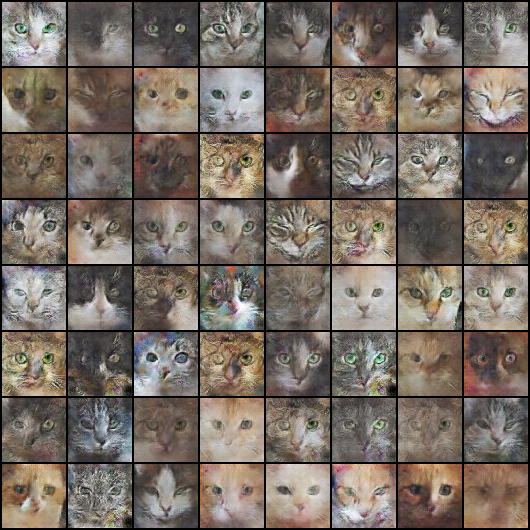

In [ ]:
Image('/content/drive/My Drive/generated/generated-images-0060.png')

In [ ]:
vid_fname = '/content/drive/My Drive/generated/gans_training.avi'

files = [os.path.join(sample_dir, f) for f in os.listdir(sample_dir) if 'generated' in f]
files.sort()

out = cv2.VideoWriter(vid_fname,cv2.VideoWriter_fourcc(*'MP4V'), 1, (530,530))
[out.write(cv2.imread(fname)) for fname in files]
out.release()

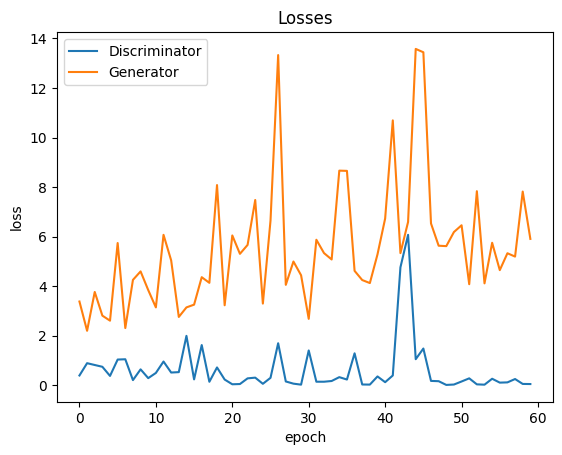

In [ ]:
plt.plot(losses_d, '-')
plt.plot(losses_g, '-')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['Discriminator', 'Generator'])
plt.title('Losses');

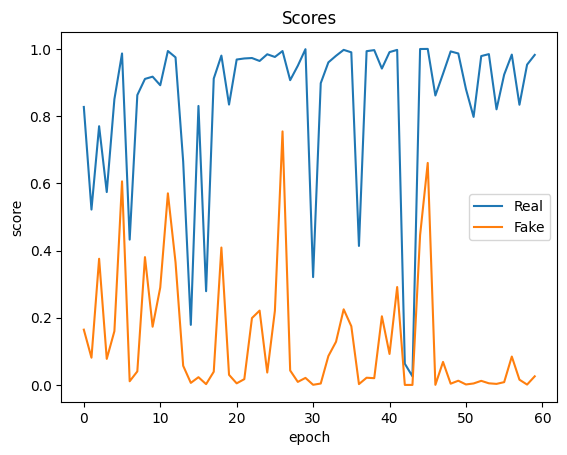

In [ ]:
plt.plot(real_scores, '-')
plt.plot(fake_scores, '-')
plt.xlabel('epoch')
plt.ylabel('score')
plt.legend(['Real', 'Fake'])
plt.title('Scores');

Saving generated-images-0100.png


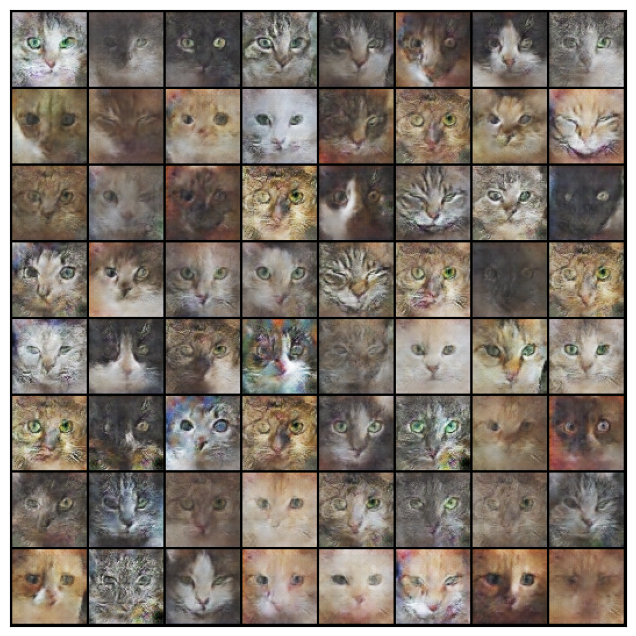

In [ ]:
save_samples(100, fixed_latent)

In [ ]:
os.listdir(sample_dir)

['generated-images-0025.png',
 'generated-images-0026.png',
 'generated-images-0027.png',
 'generated-images-0028.png',
 'generated-images-0029.png',
 'generated-images-0030.png',
 'generated-images-0031.png',
 'generated-images-0032.png',
 'generated-images-0033.png',
 'generated-images-0034.png',
 'generated-images-0035.png',
 'generated-images-0036.png',
 'generated-images-0037.png',
 'generated-images-0038.png',
 'generated-images-0039.png',
 'generated-images-0040.png',
 'generated-images-0041.png',
 'generated-images-0042.png',
 'generated-images-0043.png',
 'generated-images-0044.png',
 'generated-images-0045.png',
 'generated-images-0046.png',
 'generated-images-0047.png',
 'generated-images-0048.png',
 'generated-images-0049.png',
 'generated-images-0050.png',
 'generated-images-0051.png',
 'generated-images-0052.png',
 'generated-images-0053.png',
 'generated-images-0054.png',
 'generated-images-0055.png',
 'generated-images-0056.png',
 'generated-images-0057.png',
 'generate